In [7]:
from skyfield.api import load
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load, wgs84

# 单史料计算ΔT


“元初五年八月丙申朔，日有蚀之,在翼十八度。史官不见，张掖以闻。”——《后汉书第十八》

In [8]:
input_y = 118
input_m = 9
input_d = 3
pos_Long = 100.45 # 经度
pos_Lat = 38.95 # 纬度

In [9]:
# 1. 日期转换：儒略历转格里高利历
def calendar_to_jd(year, month, day, calendar_type="julian"):
    """将指定的历法日期转换为连续的儒略日 (JD)

    注意：天文纪年中，公元前708年对应的年份数字是 -707。
    """
    if month <= 2:
        year -= 1
        month += 12

    A = int(year / 100)

    # 根据不同的输入历法计算世纪修正值 B
    if calendar_type.lower() == "gregorian":
        B = 2 - A + int(A / 4)
    else:  # julian 历法（公元前708年选用此项）
        B = 0

    # 经典 Meeus 儒略日计算公式
    jd = (
        int(365.25 * (year + 4716))
        + int(30.6001 * (month + 1))
        + day
        + B
        - 1524.5
    )
    return jd


def jd_to_calendar(jd, to_calendar="gregorian"):
    """将中转的儒略日 (JD) 准确转换回目标历法日期"""
    jd += 0.5
    Z = int(jd)
    F = jd - Z

    if to_calendar.lower() == "gregorian":
        alpha = int((Z - 1867216.25) / 36524.25)
        A = Z + 1 + alpha - int(alpha / 4)
    else:  # 转换为儒略历
        A = Z

    B = A + 1524
    C = int((B - 122.1) / 365.25)
    D = int(365.25 * C)
    E = int((B - D) / 30.6001)

    day = B - D - int(30.6001 * E) + F
    if E < 14:
        month = E - 1
    else:
        month = E - 13

    if month > 2:
        year = C - 4716
    else:
        year = C - 4715

    return int(year), int(month), int(day)


def julian_to_gregorian_preset(year, month, day):
    """主转换核心函数：儒略历 转 格里高利历"""
    # 1. 先将输入的儒略历转换为绝对儒略日(JD)
    jd_mid = calendar_to_jd(year, month, day, calendar_type="julian")

    # 2. 再将这个 JD 转换回外推的格里高利历日期
    g_year, g_month, g_day = jd_to_calendar(jd_mid, to_calendar="gregorian")

    return g_year, g_month, g_day


if __name__ == "__main__":
    year, month, day = julian_to_gregorian_preset(input_y, input_m, input_d)

    print(f"【输入测试】儒略历: {input_y}年{input_m}月{input_d}日")
    print(f"【结果输出】格里高利历: {year}年{month}月{day}日")

【输入测试】儒略历: 118年9月3日
【结果输出】格里高利历: 118年9月2日


tt_best: <Time tt=1764403.0013888888>
(118, 9, 2, 12, 2, 0.0)
min_sep: 0.5282913563474916
视直径比例 (月/日): 1.0211880812965133 (大于1表示月亮更大，具备全食条件)
dt_theo:9218.118702684906
1764402.7083333333


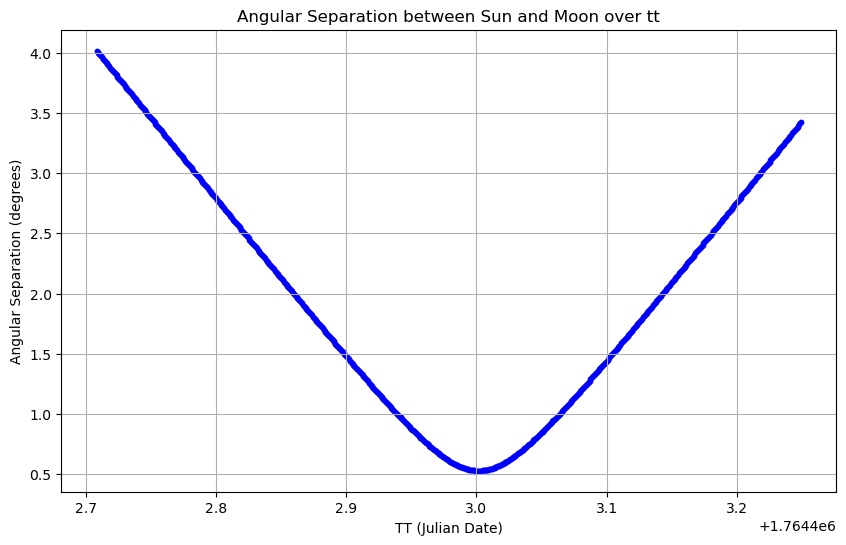

In [10]:
# 2. TT时下的可能最佳日食时间

# 1.1 加载数据
eph = load('de441.bsp')
sun, moon, earth = eph['sun'], eph['moon'], eph['earth']
ts = load.timescale()

# 1.2 已知公元历下的年月日(UT)
t_year = year 
t_month = month
t_day = day 
hour_min = 5
hour_max = 18
# 1.2.2 可能范围
hours = np.arange(hour_min, hour_max)
minutes = np.arange(0, 60)
h_mesh, m_mesh = np.meshgrid(hours, minutes) # 生成小时和分钟的网格,使得后面tt的范围形状一致


# 1.3 转化为TT时,假设与UT时在同一天(ΔT不会差到十几二十个小时...),通过日月地距离规范日全食时间
tt_min = ts.tt(t_year, t_month, t_day, hour_min)
tt_max = ts.tt(t_year, t_month, t_day, hour_max)
tt_steps = ts.tt(t_year, t_month, t_day, h_mesh.flatten(), m_mesh.flatten())

# 1.4 计算太阳、月亮在日心坐标系下的几何位置，日月地心重合时候即为日食
# 1.4.1 输出不同时刻日地、月地相对位置关系
astrometric_sun = earth.at(tt_steps).observe(sun)
astrometric_moon = earth.at(tt_steps).observe(moon) 
# 1.4.2 日心、地心、月心在一条直线上时，即日月角距离最小
separation = astrometric_sun.separation_from(astrometric_moon) # 角距离
index = np.argmin(separation.arcseconds())# 角距离最小时候的索引
tt_best = tt_steps[index] # 最合适的TT
min_sep = separation.degrees[index] # 最小角距离
print(f"tt_best: {tt_best}")
print(tt_best.tt_calendar())
print(f"min_sep: {min_sep}")
# 1.4.3 验证此时地球视角下月亮比太阳大
dist_sun = astrometric_sun[index].distance().au # 日地距离
dist_moon = astrometric_moon[index].distance().au  # 月地距离
# 视直径对比：月球距离/太阳距离 如果小于 月球半径/太阳半径，则可能发生全食
ratio = (3474 / dist_moon) / (1392700 / dist_sun)
print(f"视直径比例 (月/日): {ratio} (大于1表示月亮更大，具备全食条件)")

# 1.5 理论ΔT
dt_best_theo = tt_best.delta_t
print(f"dt_theo:{tt_best.delta_t}")
print(tt_steps.tt[0])
# 1.6 对角距离关系进行绘图
plt.figure(figsize=(10, 6))
plt.title("Angular Separation between Sun and Moon over tt")
plt.xlabel("TT (Julian Date)")
plt.ylabel("Angular Separation (degrees)")
plt.grid()
plt.scatter(tt_steps.tt, separation.degrees, s=10, color='blue', label='Angular Separation')

In [11]:
# 3. 求 ΔT
# 1. 初始化
eph = load('de441.bsp')
sun, moon, earth = eph['sun'], eph['moon'], eph['earth']
ts = load.timescale()
qufu = earth + wgs84.latlon(pos_Lat, pos_Long) # 地理位置，(纬度，经度)

year, m, d = year, month, day
# 保持高密度采样

ut1_hours = np.arange(hour_min, hour_max, 30/60.0)  # 半分钟采一次样
t_temp = ts.ut1(year, m, d, ut1_hours)
t_temp_skyfield_dt_min = min(t_temp.delta_t)
t_temp_skyfield_dt_max = max(t_temp.delta_t)
#print(f"skyfield计算的ΔT: {t_temp.delta_t}")

def check_totality(test_dt):
    # A.  TT = UT1 + Delta_T
    # 我们先得到一系列 TT 的儒略日
    t_temp = ts.ut1(year, m, d, ut1_hours)
    # 计算对应的 TT 儒略日：当前的 UT1 + 我们要测试的 Delta T
    jd_tt = t_temp.ut1 + test_dt / 86400.0
    
    # B. 使用官方推荐的 tt_jd 构造时间对象
    # 此时生成的 t 对象，其内置的 delta_t 是 Skyfield 用默认模型算出来的
    t = ts.tt_jd(jd_tt) 
    
    # C. 【核心黑客操作】强制覆盖该对象的 delta_t 属性
    # Skyfield 计算地面位置时会读取 t.delta_t
    t.delta_t = np.array([test_dt] * len(jd_tt))
    
    # 3. 几何判定
    obs_s = qufu.at(t).observe(sun).apparent()
    obs_m = qufu.at(t).observe(moon).apparent()
    
    sep = obs_s.separation_from(obs_m).radians
    # 使用 IAU 常数和更精确的半径计算
    r_sun = np.arcsin(695700.0 / obs_s.distance().km)
    r_moon = np.arcsin(1737.4 / obs_m.distance().km)
    
    is_bigger = r_moon > r_sun
    is_covered = sep < (r_moon + r_sun)  # 缩小范围
    
    return np.any(is_bigger & is_covered)

# 4. 执行扫描
dt_range = np.arange(t_temp_skyfield_dt_min-5000, t_temp_skyfield_dt_max+5000, 20) # 步长缩短到 1s 提高命中率
valid_dts = []

print("正在扫描 ΔT...")
for d_t in dt_range:
    if check_totality(d_t):
        valid_dts.append(d_t)

if valid_dts:
    print("-" * 40)
    print(f"复现范围: {min(valid_dts)} s ~ {max(valid_dts)} s")
#    print(f"论文参考: 20264 s ~ 21204 s")
else:
    print("未找到结果。")


正在扫描 ΔT...
----------------------------------------
复现范围: 4218.10959817058 s ~ 14218.10959817058 s


开始高精度扫描，请稍候...
计算完成，开始绘图...


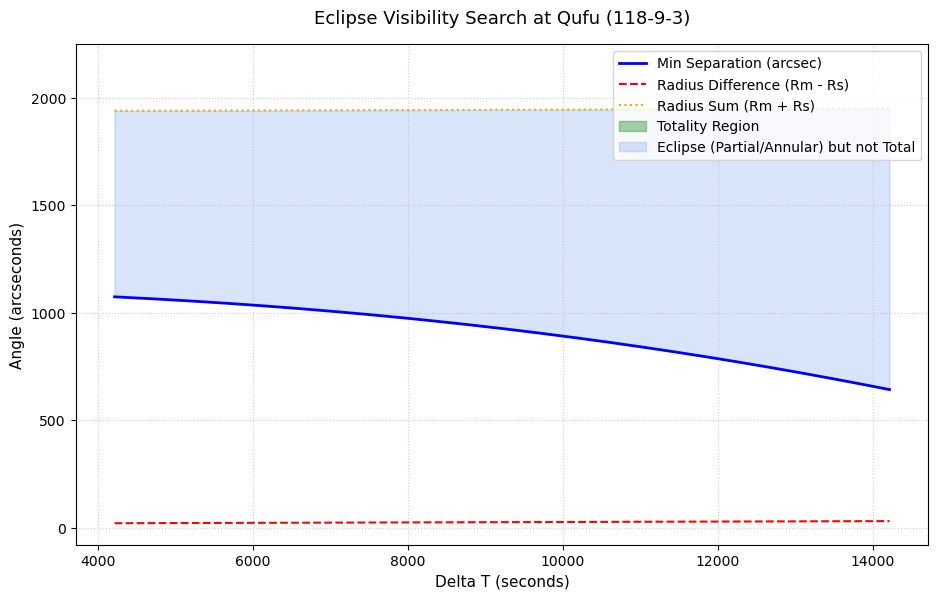

In [ ]:
# 4. 可视化

# 1. 设置 Delta T 扫描参数
dt_test_range = np.arange(t_temp_skyfield_dt_min - 5000, t_temp_skyfield_dt_max + 5000, 50)  # 步长 50s

min_seps = []
radius_diffs = []      # (r_moon - r_sun)
r_sun_list = []        # 存储最佳时刻的太阳视半径
r_moon_list = []       # 存储最佳时刻的月球视半径

print("开始高精度扫描，请稍候...")

for d_t in dt_test_range:
    # --- 阶段 A：粗搜索（快速定位最接近的小时段） ---
    t_coarse_temp = ts.ut1(year, m, d, ut1_hours)
    jd_tt_coarse = t_coarse_temp.ut1 + d_t / 86400.0
    t_coarse = ts.tt_jd(jd_tt_coarse)
    t_coarse.delta_t = np.array([d_t] * len(jd_tt_coarse))
    
    obs_s_c = qufu.at(t_coarse).observe(sun).apparent()
    obs_m_c = qufu.at(t_coarse).observe(moon).apparent()
    seps_coarse = obs_s_c.separation_from(obs_m_c).arcseconds()
    
    # 找到粗搜最接近的索引，并在其前后扩展 0.6 小时进行精搜
    best_coarse_idx = np.argmin(seps_coarse)
    center_hour = ut1_hours[best_coarse_idx]
    
    # --- 阶段 B：高精度精搜索（1秒步长逼近真实食甚） ---
    # 1秒 = 1/3600 小时
    ut1_hours_fine = np.arange(center_hour - 0.6, center_hour + 0.6, 1.0 / 3600.0)
    
    t_temp = ts.ut1(year, m, d, ut1_hours_fine)
    jd_tt = t_temp.ut1 + d_t / 86400.0
    t = ts.tt_jd(jd_tt)
    t.delta_t = np.array([d_t] * len(jd_tt))
    
    # 计算视位置
    obs_s = qufu.at(t).observe(sun).apparent()
    obs_m = qufu.at(t).observe(moon).apparent()
    
    # 计算角距离和视半径
    seps = obs_s.separation_from(obs_m).arcseconds()
    r_s = np.degrees(np.arcsin(695700.0 / obs_s.distance().km)) * 3600
    r_m = np.degrees(np.arcsin(1737.4 / obs_m.distance().km)) * 3600
    
    # 记录该 Delta T 下真正的最优值
    best_idx = np.argmin(seps)
    min_seps.append(seps[best_idx])
    radius_diffs.append(r_m[best_idx] - r_s[best_idx])
    r_sun_list.append(r_s[best_idx])    
    r_moon_list.append(r_m[best_idx])   

# 转换为 numpy 数组
min_seps = np.array(min_seps)
radius_diffs = np.array(radius_diffs)
r_sun_arr = np.array(r_sun_list)      
r_moon_arr = np.array(r_moon_list)    
sum_radii = r_sun_arr + r_moon_arr    # 太阳与月亮视半径之和

print("计算完成，开始绘图...")

# 2. 日食条件判定
# 日全食条件：最小角距离 < 半径差，且月亮比太阳大
is_total = (min_seps < radius_diffs) & (radius_diffs > 0)
# 广义日食条件（只要有遮挡）：最小角距离 < 半径之和
is_eclipse = min_seps < sum_radii 
is_eclipse_not_total = is_eclipse & ~is_total  # 是日食但不是全食

# 3. 绘图
plt.figure(figsize=(11, 6.5), dpi=100)

# 绘制三条核心数据线
plt.plot(dt_test_range, min_seps, label='Min Separation (arcsec)', color='blue', lw=2)
plt.plot(dt_test_range, radius_diffs, label='Radius Difference (Rm - Rs)', color='red', linestyle='--')
plt.plot(dt_test_range, sum_radii, label='Radius Sum (Rm + Rs)', color='orange', linestyle=':')

# 日全食区域：填充 Y=0 到 Y=min_seps
plt.fill_between(dt_test_range, 0, min_seps, where=is_total, 
                 color='forestgreen', alpha=0.4, label='Totality Region')

# 非全食的日食区域（偏食/环食）：填充从 min_seps 到 sum_radii 的夹角
plt.fill_between(dt_test_range, min_seps, sum_radii, where=is_eclipse_not_total, 
                 color='cornflowerblue', alpha=0.25, label='Eclipse (Partial/Annular) but not Total')


plt.xlabel('Delta T (seconds)', fontsize=11)
plt.ylabel('Angle (arcseconds)', fontsize=11)
plt.title(f'Eclipse Visibility Search at Qufu ({input_y}-{input_m}-{input_d})', fontsize=13, pad=15)
plt.legend(loc='upper right', frameon=True, shadow=False)
plt.grid(True, linestyle=':', alpha=0.6)

y_min = np.min(radius_diffs) - 100
if np.any(is_eclipse):
    y_max = np.max(sum_radii) + 300
else:
    y_max = np.max(min_seps) + 200
plt.ylim(y_min, y_max)

plt.show()